# Segmentação de Fundos de Investimento no Brasil com Machine Learning

Projeto final desenvolvido para a entrega **Projeto de Parceria | Semantix**.

O objetivo é segmentar fundos de investimento em perfis semelhantes usando variáveis financeiras como patrimônio líquido, número de cotistas, captação, resgate, retorno e volatilidade.

**Técnicas utilizadas:** análise exploratória, engenharia de variáveis, padronização, K-means, Silhouette Score e PCA.

> Este projeto tem finalidade educacional e não constitui recomendação de investimento.


## 1. Importação das bibliotecas

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 80)

## 2. Configuração da pasta do projeto

In [2]:
def encontrar_pasta_projeto():
    candidatos = [Path.cwd(), Path('/content'), Path('/mnt/data')]
    for raiz in candidatos:
        if raiz.exists():
            encontrados = list(raiz.rglob('data/amostra_fundos_cvm_demonstrativa.csv'))
            if encontrados:
                return encontrados[0].parents[1]
    return Path.cwd()

BASE_DIR = encontrar_pasta_projeto()
os.chdir(BASE_DIR)
DATA_DIR = BASE_DIR / 'data'
DOCS_DIR = BASE_DIR / 'docs'
IMAGES_DIR = BASE_DIR / 'images'

print('Pasta do projeto:', BASE_DIR)
print('Base encontrada:', (DATA_DIR / 'amostra_fundos_cvm_demonstrativa.csv').exists())

Pasta do projeto: projeto-semantix-fundos-ml
Base encontrada: True


## 3. Carregamento dos dados

In [3]:
df = pd.read_csv(DATA_DIR / 'amostra_fundos_cvm_demonstrativa.csv')
print('Dimensão da base:', df.shape)
df.head()

Dimensão da base: (820, 14)


,CNPJ_FUNDO,DENOM_SOCIAL,CLASSE,PUBLICO_ALVO,patrimonio_liquido_medio,cotistas_medio,captacao_total,resgate_total,captacao_liquida,movimentacao_total,retorno_periodo,volatilidade_cota,dias_observados,perfil_original_amostra
0,10000000000100,FUNDO DEMONSTRATIVO 0001,Ações,Qualificado,1.904708e+09,2038,0.00,15169409.79,-15169409.79,15169409.79,0.010503,0.008138,21,Grande porte e estável
1,10000000000101,FUNDO DEMONSTRATIVO 0002,Renda Fixa,Qualificado,1.007589e+09,8600,20392221.34,12253301.63,8138919.71,32645522.97,0.010667,0.004291,18,Grande porte e estável
2,10000000000102,FUNDO DEMONSTRATIVO 0003,Ações,Qualificado,9.506101e+08,8594,14450610.60,0.00,14450610.60,14450610.60,0.005700,0.003187,22,Grande porte e estável
3,10000000000103,FUNDO DEMONSTRATIVO 0004,Renda Fixa,Público Geral,2.158696e+09,5849,43470442.30,50558293.56,-7087851.26,94028735.87,0.008476,0.005896,19,Grande porte e estável
4,10000000000104,FUNDO DEMONSTRATIVO 0005,Renda Fixa,Qualificado,2.260357e+09,10370,24172726.31,534574.91,23638151.40,24707301.22,0.005316,0.000500,21,Grande porte e estável


## 4. Entendimento inicial

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CNPJ_FUNDO                820 non-null    int64  
 1   DENOM_SOCIAL              820 non-null    object 
 2   CLASSE                    820 non-null    object 
 3   PUBLICO_ALVO              820 non-null    object 
 4   patrimonio_liquido_medio  820 non-null    float64
 5   cotistas_medio            820 non-null    int64  
 6   captacao_total            820 non-null    float64
 7   resgate_total             820 non-null    float64
 8   captacao_liquida          820 non-null    float64
 9   movimentacao_total        820 non-null    float64
 10  retorno_periodo           820 non-null    float64
 11  volatilidade_cota         820 non-null    float64
 12  dias_observados           820 non-null    int64  
 13  perfil_original_amostra   820 non-null    object 
dtypes: float64

In [5]:
df.describe(include='all').T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CNPJ_FUNDO,820.0,NaN,NaN,NaN,10000000000509.5,236.857904,10000000000100.0,10000000000304.75,10000000000509.5,10000000000714.25,10000000000919.0
DENOM_SOCIAL,820,820,FUNDO DEMONSTRATIVO 0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLASSE,820,4,Renda Fixa,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PUBLICO_ALVO,820,3,Público Geral,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patrimonio_liquido_medio,820.0,NaN,NaN,NaN,418474761.940915,864432511.409819,2711195.6,17244732.17,45954385.205,148541456.895,7551907170.53
cotistas_medio,820.0,NaN,NaN,NaN,1386.560976,2976.640085,8.0,81.0,271.0,934.0,31202.0
captacao_total,820.0,NaN,NaN,NaN,6829452.7025,12034035.213897,0.0,450662.915,1974024.26,7332650.1875,117272997.85
resgate_total,820.0,NaN,NaN,NaN,5627681.195329,10289258.775106,0.0,403193.5,1839408.6,6298811.9025,96169834.46
captacao_liquida,820.0,NaN,NaN,NaN,1201771.507085,10062676.235222,-69911062.4,-272482.4825,33920.74,575319.91,91496136.33
movimentacao_total,820.0,NaN,NaN,NaN,12457133.897841,20002905.947267,25219.73,970161.63,4521042.985,14812470.16,149975473.69


In [6]:
print('Valores nulos por coluna:')
df.isna().sum().sort_values(ascending=False).head(10)

Valores nulos por coluna:


,0
CNPJ_FUNDO,0
DENOM_SOCIAL,0
CLASSE,0
PUBLICO_ALVO,0
patrimonio_liquido_medio,0
cotistas_medio,0
captacao_total,0
resgate_total,0
captacao_liquida,0
movimentacao_total,0


## 5. Engenharia de variáveis

In [7]:
df_model = df.copy()
df_model['log_patrimonio_liquido'] = np.log1p(df_model['patrimonio_liquido_medio'])
df_model['log_cotistas'] = np.log1p(df_model['cotistas_medio'])
df_model['captacao_liquida_sobre_pl'] = df_model['captacao_liquida'] / df_model['patrimonio_liquido_medio']
df_model['movimentacao_sobre_pl'] = df_model['movimentacao_total'] / df_model['patrimonio_liquido_medio']

features = [
    'log_patrimonio_liquido',
    'log_cotistas',
    'captacao_liquida_sobre_pl',
    'movimentacao_sobre_pl',
    'retorno_periodo',
    'volatilidade_cota'
]

print('Variáveis usadas na modelagem:')
print(features)
df_model[features].describe().T

Variáveis usadas na modelagem:
['log_patrimonio_liquido', 'log_cotistas', 'captacao_liquida_sobre_pl', 'movimentacao_sobre_pl', 'retorno_periodo', 'volatilidade_cota']


,count,mean,std,min,25%,50%,75%,max
patrimonio_liquido_medio,820.0,4.184748e+08,8.644325e+08,2.711196e+06,1.724473e+07,4.595439e+07,1.485415e+08,7.551907e+09
cotistas_medio,820.0,1.386561e+03,2.976640e+03,8.000000e+00,8.100000e+01,2.710000e+02,9.340000e+02,3.120200e+04
captacao_liquida,820.0,1.201772e+06,1.006268e+07,-6.991106e+07,-2.724825e+05,3.392074e+04,5.753199e+05,9.149614e+07
movimentacao_total,820.0,1.245713e+07,2.000291e+07,2.521973e+04,9.701616e+05,4.521043e+06,1.481247e+07,1.499755e+08
retorno_periodo,820.0,7.918946e-03,1.283471e-02,-3.851914e-02,4.577575e-04,5.395278e-03,1.067206e-02,7.423485e-02
volatilidade_cota,820.0,1.381791e-02,1.243738e-02,5.000000e-04,4.990441e-03,1.091372e-02,1.851539e-02,7.292817e-02


## 6. Análise exploratória

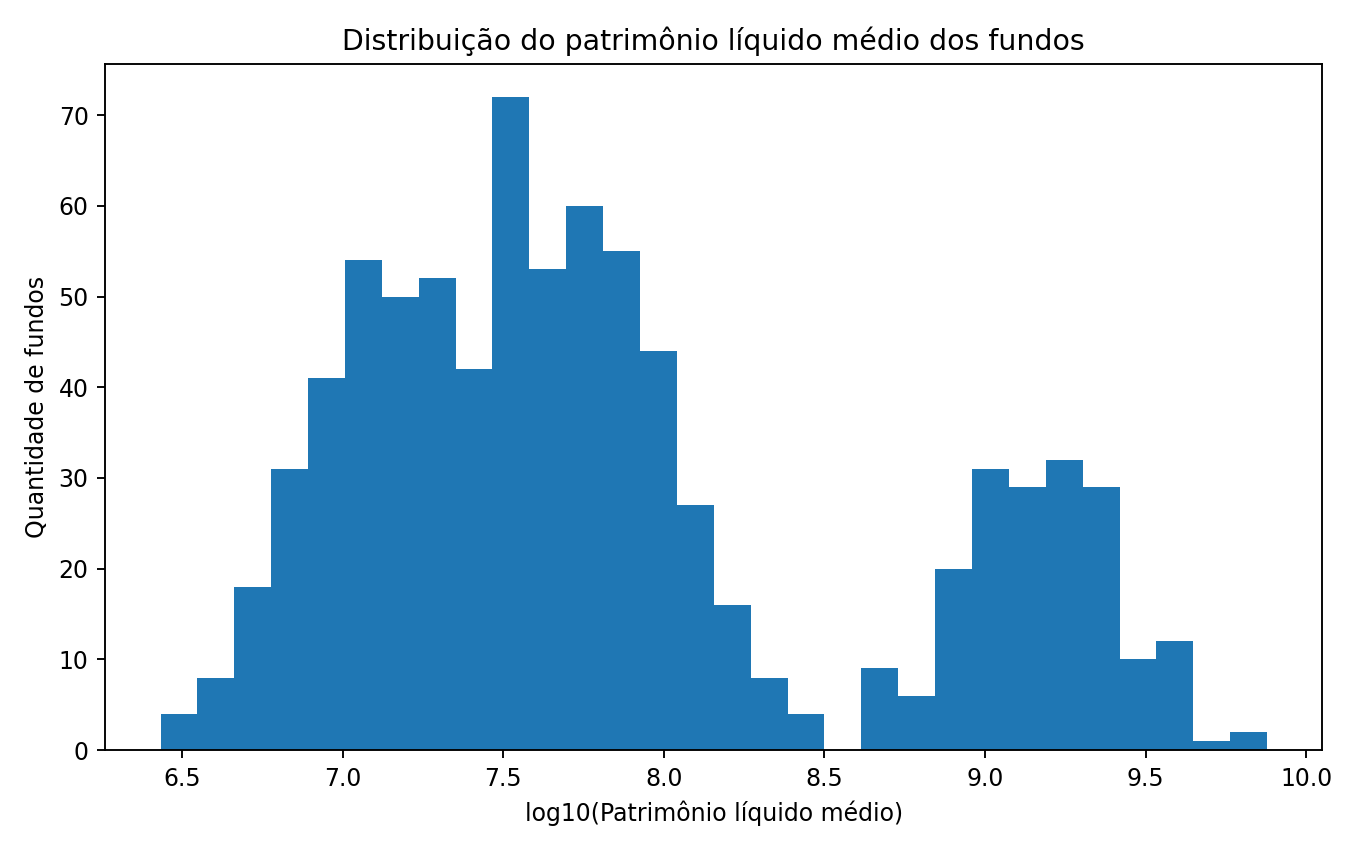

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(np.log10(df_model['patrimonio_liquido_medio']), bins=30)
plt.title('Distribuição do patrimônio líquido médio dos fundos')
plt.xlabel('log10(Patrimônio líquido médio)')
plt.ylabel('Quantidade de fundos')
plt.tight_layout()
plt.show()

In [9]:
if 'CLASSE' in df_model.columns:
    df_model['CLASSE'].value_counts()

,count
CLASSE,
Renda Fixa,380
Multimercado,237
Ações,170
Cambial,33


## 7. Treinamento do K-means e avaliação

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

resultados_k = []
for k in range(2, 8):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = modelo.fit_predict(X_scaled)
    resultados_k.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'inertia': modelo.inertia_
    })

metricas_k = pd.DataFrame(resultados_k)
melhor_k = int(metricas_k.sort_values('silhouette', ascending=False).iloc[0]['k'])
print('Melhor k pelo Silhouette Score:', melhor_k)
metricas_k

Melhor k pelo Silhouette Score: 4


,k,silhouette
0,2,0.351129
1,3,0.358009
2,4,0.361926
3,5,0.334128
4,6,0.311324
5,7,0.291752


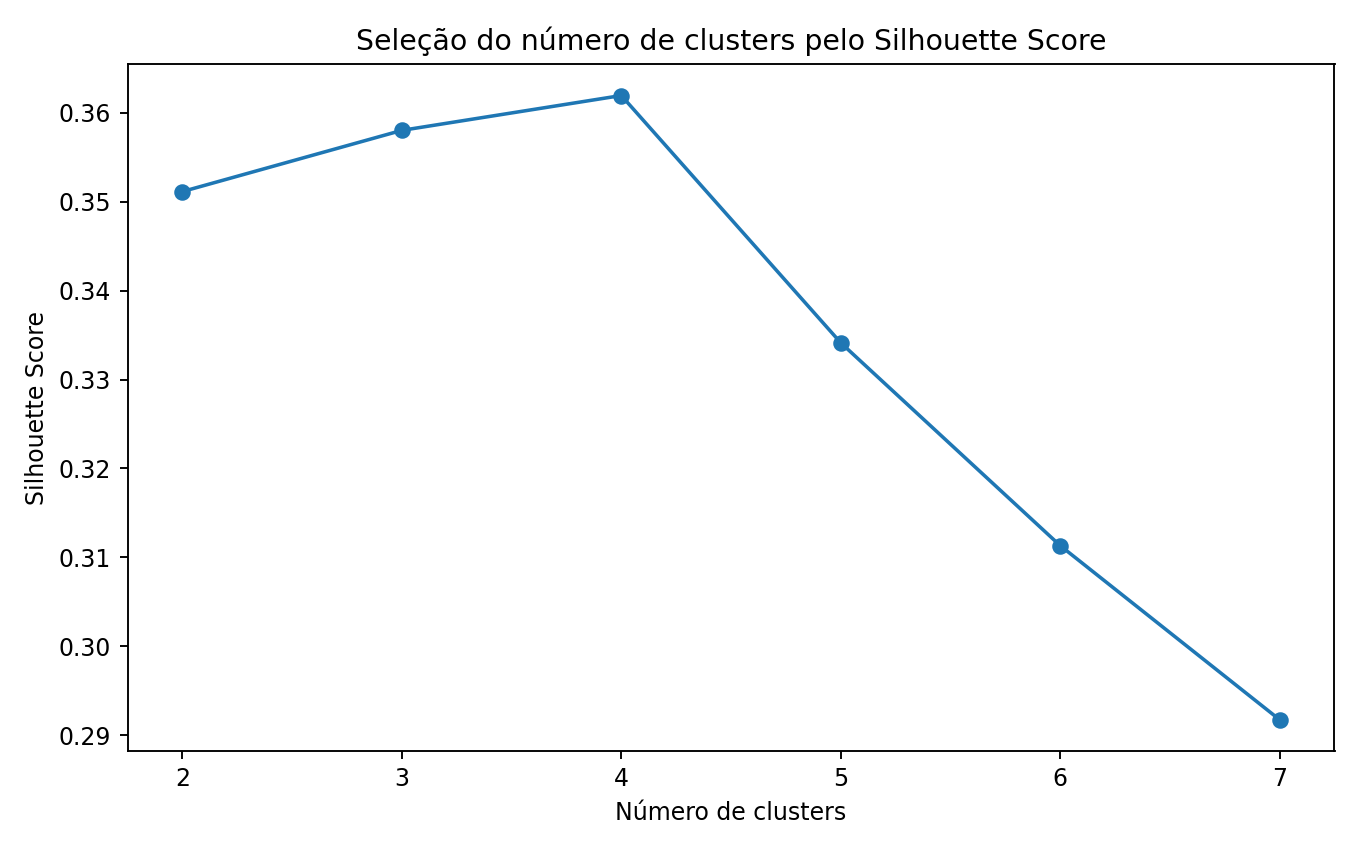

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(metricas_k['k'], metricas_k['silhouette'], marker='o')
plt.title('Seleção do número de clusters pelo Silhouette Score')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

## 8. Visualização com PCA

In [12]:
kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=20)
df_model['cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)
df_model['PC1'] = pca_data[:, 0]
df_model['PC2'] = pca_data[:, 1]

print('Clusters encontrados:', sorted(df_model['cluster'].unique()))

Clusters encontrados: [0, 1, 2, 3]


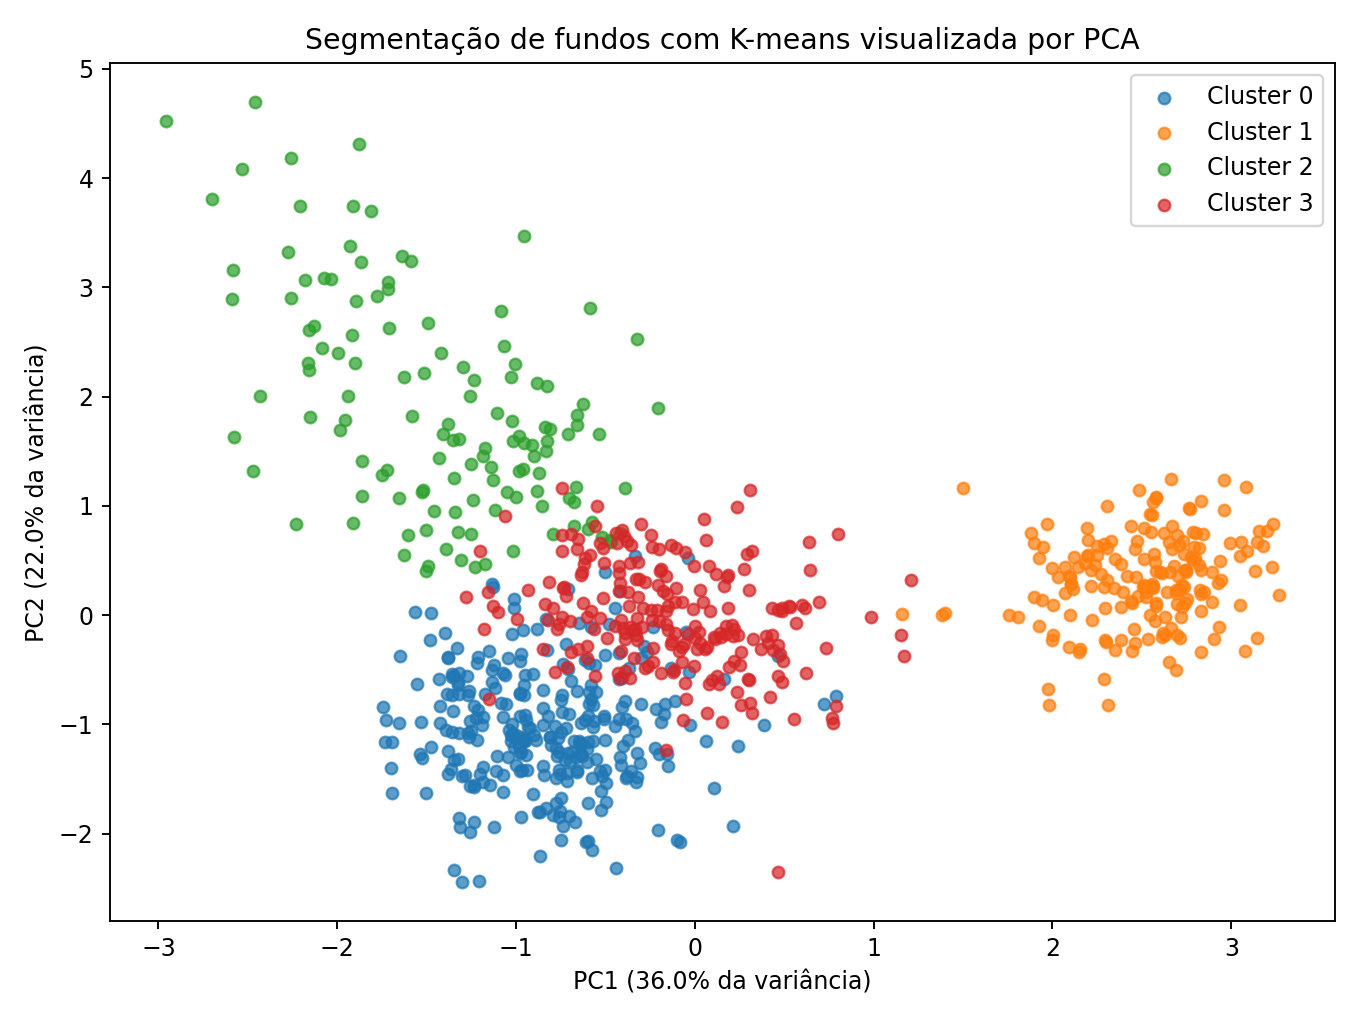

In [13]:
plt.figure(figsize=(8, 6))
for cluster, group in df_model.groupby('cluster'):
    plt.scatter(group['PC1'], group['PC2'], s=24, alpha=0.7, label=f'Cluster {cluster}')
plt.title('Segmentação de fundos com K-means visualizada por PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Perfil dos clusters

In [14]:
perfil_clusters = pd.read_csv(DOCS_DIR / 'perfil_clusters_amostra.csv')
perfil_clusters

,cluster,qtd_fundos,patrimonio_liquido_mediano,cotistas_mediano,retorno_mediano,volatilidade_mediana,captacao_liquida_sobre_pl_mediana,movimentacao_sobre_pl_mediana,perfil_interpretado
0,0.0,290,1.304171e+07,63.0,0.003292,0.010320,-0.001056,0.056222,Pequeno porte
1,1.0,180,1.479044e+09,4070.5,0.006069,0.003774,0.003221,0.020938,Grande porte e pulverizado
2,2.0,129,3.666619e+07,225.0,0.027726,0.032831,-0.001702,0.086792,Maior risco/retorno
3,3.0,221,7.306512e+07,415.0,0.003424,0.013553,0.004941,0.140573,Alta movimentação


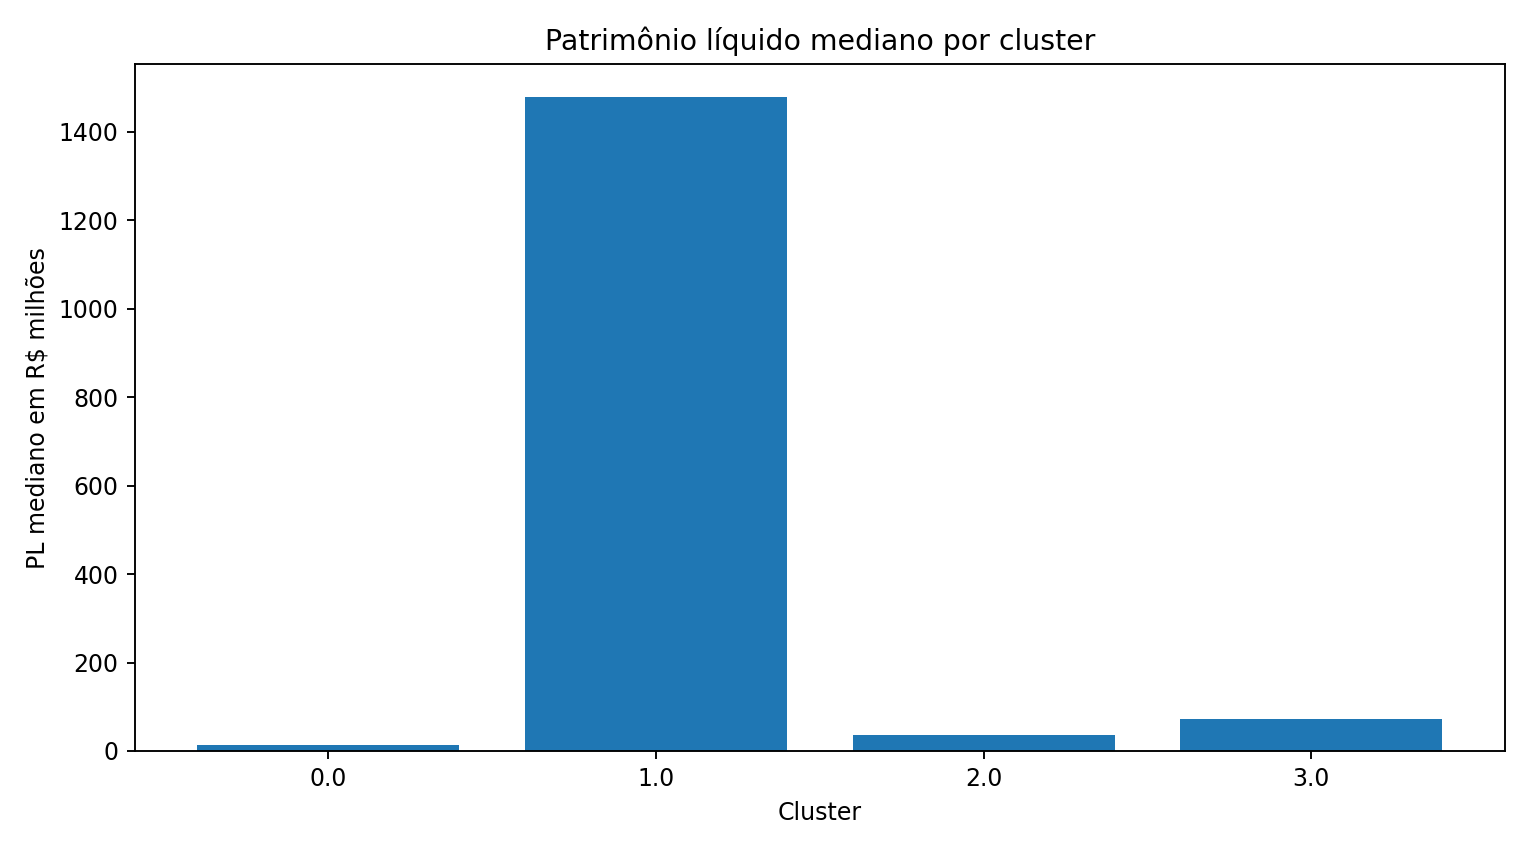

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(perfil_clusters['cluster'].astype(str), perfil_clusters['patrimonio_liquido_mediano'] / 1_000_000)
plt.title('Patrimônio líquido mediano por cluster')
plt.xlabel('Cluster')
plt.ylabel('PL mediano em R$ milhões')
plt.tight_layout()
plt.show()

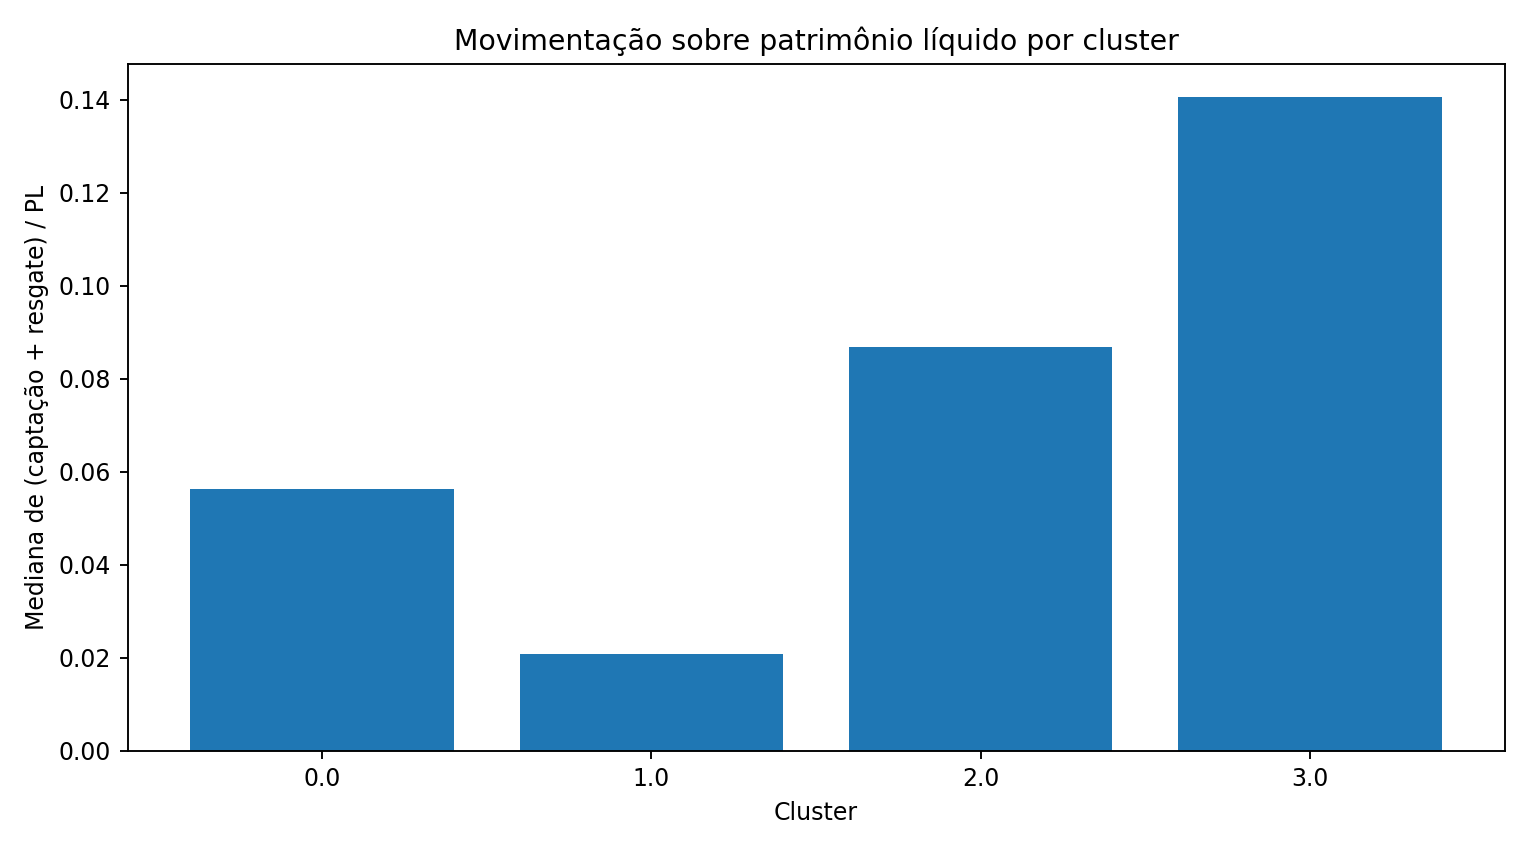

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(perfil_clusters['cluster'].astype(str), perfil_clusters['movimentacao_sobre_pl_mediana'])
plt.title('Movimentação sobre patrimônio líquido por cluster')
plt.xlabel('Cluster')
plt.ylabel('Mediana de (captação + resgate) / PL')
plt.tight_layout()
plt.show()

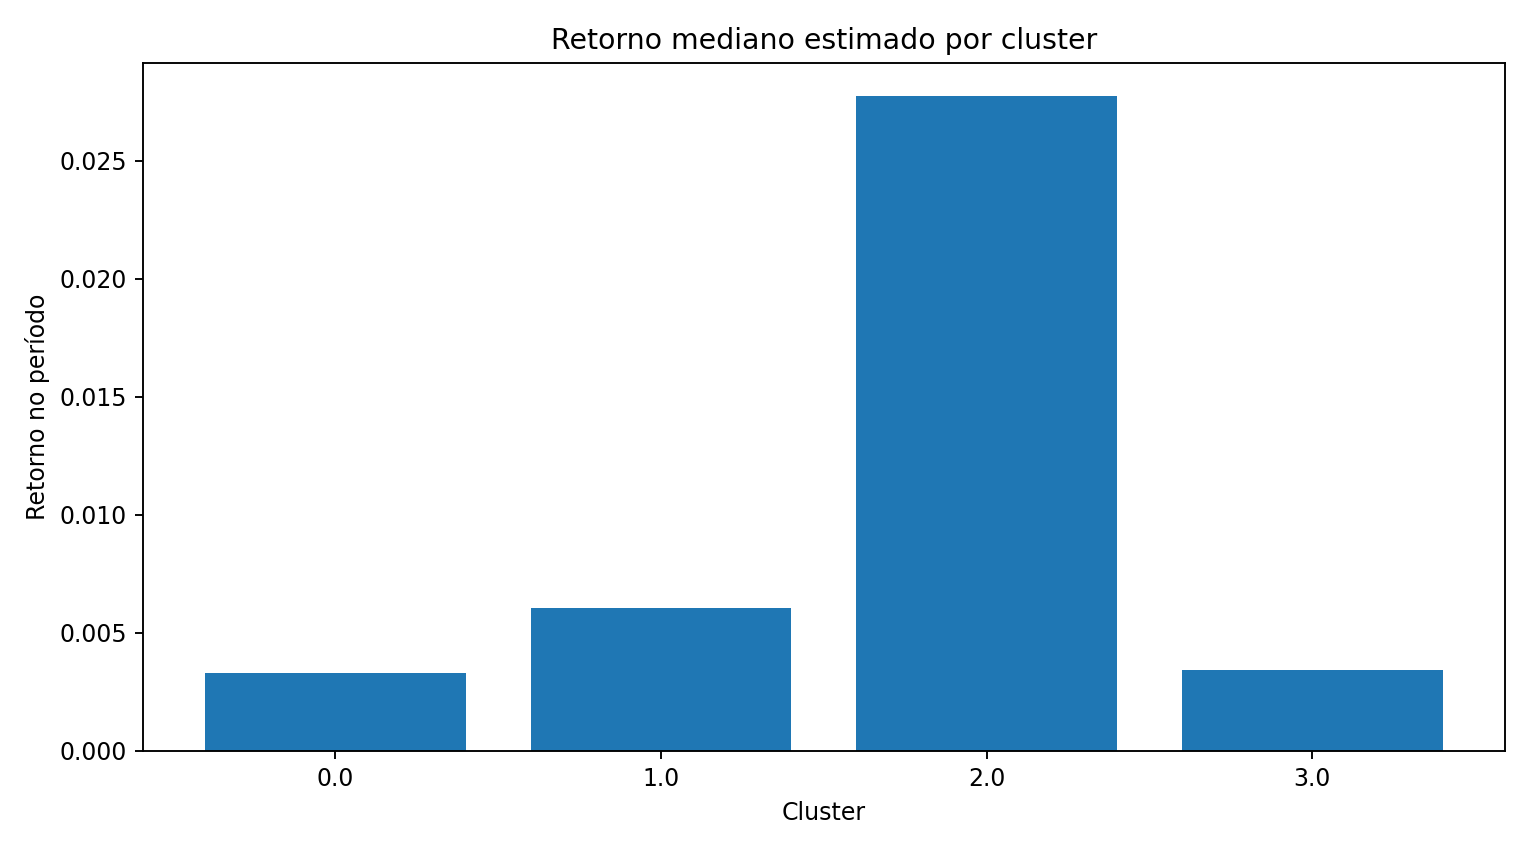

In [17]:
plt.figure(figsize=(9, 5))
plt.bar(perfil_clusters['cluster'].astype(str), perfil_clusters['retorno_mediano'])
plt.title('Retorno mediano estimado por cluster')
plt.xlabel('Cluster')
plt.ylabel('Retorno no período')
plt.tight_layout()
plt.show()

## 10. Conclusão

O projeto demonstrou que técnicas de Machine Learning não supervisionado podem apoiar a análise de fundos de investimento.

Principais conclusões:

- O K-means permitiu criar grupos de fundos com características semelhantes.
- O Silhouette Score foi usado para justificar a escolha do número de clusters.
- O PCA facilitou a visualização dos agrupamentos.
- Os clusters podem ser interpretados por porte, base de cotistas, movimentação, retorno e volatilidade.
- A abordagem pode apoiar análise de mercado, comparação de fundos e construção de dashboards financeiros.
